<a href="https://colab.research.google.com/github/HannaPutti/Anomaly-Detection/blob/main/Anomaly_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q statsforecast datasetsforecast neuralforecast pytorch-forecasting lightning "pyod==1.1.2"

# Download the book's repo (contains the taxi dataset) and move into it
!git clone --depth 1 https://github.com/PacktPublishing/Deep-Learning-for-Time-Series-Data-Cookbook.git
%cd Deep-Learning-for-Time-Series-Data-Cookbook
!ls assets/datasets/taxi

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.5/160.5 kB 11.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 501.8/501.8 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.3/425.3 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.3/849.3 kB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.7/348.7 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.6/831.6 kB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 MB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.3/165.3 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 42.2 MB/s eta

##Shared setup (data loading and plotting helpers)

In [15]:
%matplotlib inline
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec

# ---------- Load the NYC taxi dataset and label anomalies ----------
dataset = pd.read_csv("Deep-Learning-for-Time-Series-Data-Cookbook/assets/datasets/taxi/taxi_data.csv")
labels = pd.read_csv("Deep-Learning-for-Time-Series-Data-Cookbook/assets/datasets/taxi/taxi_labels.csv")

dataset["ds"] = pd.Series([datetime.fromtimestamp(x) for x in dataset["timestamp"]])
dataset = dataset.drop("timestamp", axis=1)
dataset["unique_id"] = "NYT"
dataset = dataset.rename(columns={"value": "y"})

is_anomaly = []
for i, r in labels.iterrows():
    dt_start = datetime.fromtimestamp(r.start)
    dt_end = datetime.fromtimestamp(r.end)
    is_anomaly.append([dt_start <= x <= dt_end for x in dataset["ds"]])

dataset["is_anomaly"] = pd.DataFrame(is_anomaly).any(axis=0).astype(int)
dataset["ds"] = pd.to_datetime(dataset["ds"])

print(dataset.shape)
display(dataset.head())

# ---------- Plotting helpers ----------
def find_anomaly_periods(anomaly_series):
    change_points = anomaly_series.diff().fillna(0).abs()
    change_indices = change_points[change_points > 0].index
    return list(zip(change_indices[::2], change_indices[1::2]))


def plot_anomalies(ax, anomaly_periods):
    for start, end in anomaly_periods:
        ax.axvspan(start, end, color="red", alpha=0.3)


def setup_plot(ds, anomaly_periods, lab="True Values"):
    """Single panel: a line + red anomaly zones."""
    plt.figure(figsize=(15, 6))
    ax1 = plt.subplot()
    ax1.plot(ds.index, ds["y"], label=lab, color="blue", linewidth=2)
    plot_anomalies(ax1, anomaly_periods)
    ax1.set_title(f"{lab} with marked anomalous samples", fontsize=16)
    ax1.set_ylabel(lab, fontsize=14)
    ax1.legend(loc="upper left", fontsize=12)
    ax1.grid(True, which="major", linestyle="--", linewidth=0.5, color="grey")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


def setup_plot_prob(ds, anomaly_periods):
    """Two panels: series on top, predicted anomaly probability below."""
    plt.figure(figsize=(15, 10))
    gs = gridspec.GridSpec(2, 1, height_ratios=[1, 1])

    ax1 = plt.subplot(gs[0])
    ax1.plot(ds.index, ds["y"], label="True Values", color="blue", linewidth=2)
    plot_anomalies(ax1, anomaly_periods)
    ax1.set_title("True Values with Anomalies", fontsize=16)
    ax1.set_ylabel("True Values", fontsize=14)
    ax1.legend(loc="upper left", fontsize=12)
    ax1.grid(True, which="major", linestyle="--", linewidth=0.5, color="grey")

    ax2 = plt.subplot(gs[1], sharex=ax1)
    ax2.plot(ds.index, ds["Predicted Probability"],
             label="Predicted Probability of Anomaly", color="green", linewidth=2)
    plot_anomalies(ax2, anomaly_periods)
    ax2.set_title("Predicted Probability of Anomaly", fontsize=16)
    ax2.set_ylabel("Probability", fontsize=14)
    ax2.set_xlabel("Date", fontsize=14)
    ax2.legend(loc="upper left", fontsize=12)
    ax2.grid(True, which="major", linestyle="--", linewidth=0.5, color="grey")

    plt.setp(ax1.get_xticklabels(), visible=False)
    ax2.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax2.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax2.xaxis.get_major_locator()))
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

(10320, 4)


,y,ds,unique_id,is_anomaly
0,10844.0,2014-06-30 22:00:00,NYT,0
1,8127.0,2014-06-30 22:30:00,NYT,0
2,6210.0,2014-06-30 23:00:00,NYT,0
3,4656.0,2014-06-30 23:30:00,NYT,0
4,3820.0,2014-07-01 00:00:00,NYT,0


##type 1 : ARIMA (uses the M3 dataset)

Number of anomalies found: 1


/usr/local/lib/python3.13/dist-packages/utilsforecast/processing.py:406: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
/usr/local/lib/python3.13/dist-packages/utilsforecast/processing.py:462: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  freq = pd.tseries.frequencies.to_offset(freq)


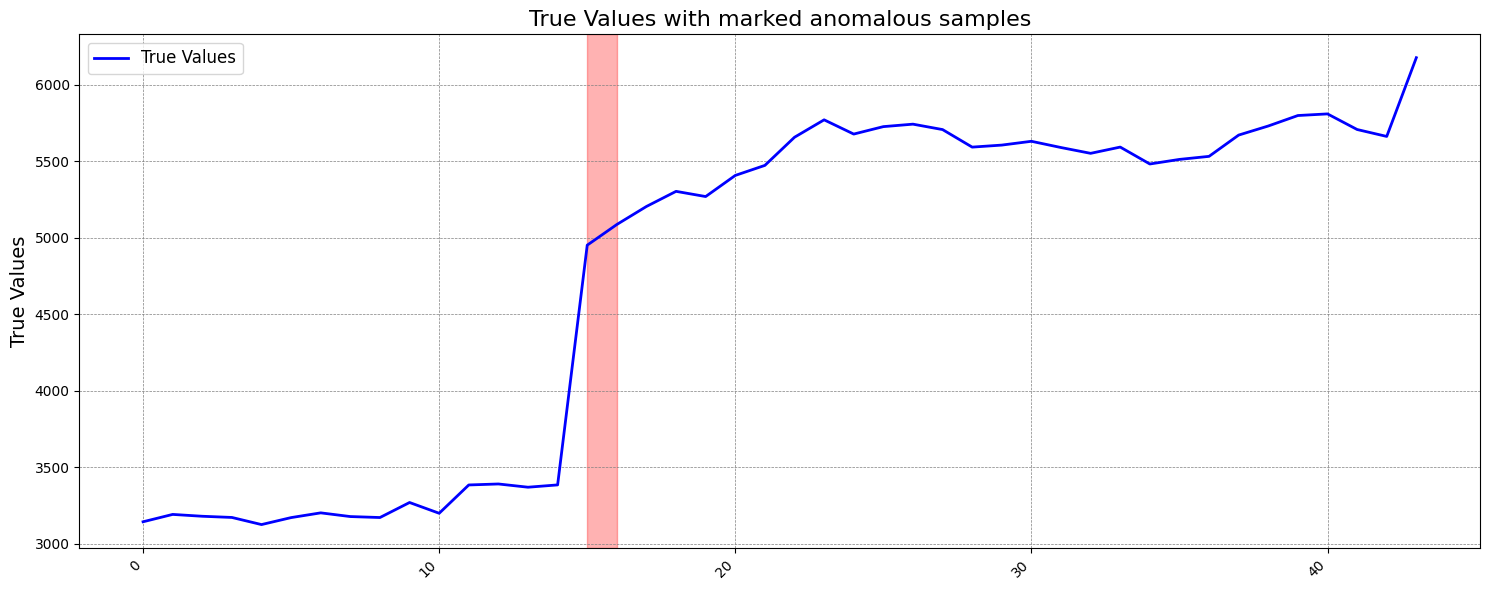

In [16]:
from datasetsforecast.m3 import M3
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA

m3, *_ = M3.load("./assets/data", "Quarterly")
q1 = m3.query('unique_id=="Q1"')

models = [AutoARIMA(season_length=4)]
sf = StatsForecast(models=models, freq="Q", n_jobs=1)
sf.fit(q1)

# 99% prediction intervals + fitted (in-sample) values
forecasts = sf.forecast(df=q1, h=8, level=[99], fitted=True).reset_index()
insample_forecasts = sf.forecast_fitted_values().reset_index()

# Anomaly = real value outside the 99% interval
anomaly_series = (
    (insample_forecasts["y"] >= insample_forecasts["AutoARIMA-hi-99"])
    | (insample_forecasts["y"] <= insample_forecasts["AutoARIMA-lo-99"])
)
print("Number of anomalies found:", anomaly_series.sum())

anomaly_periods = find_anomaly_periods(anomaly_series)
setup_plot(insample_forecasts, anomaly_periods, "True Values")

##type 2 : NHITS prediction-based deep learning

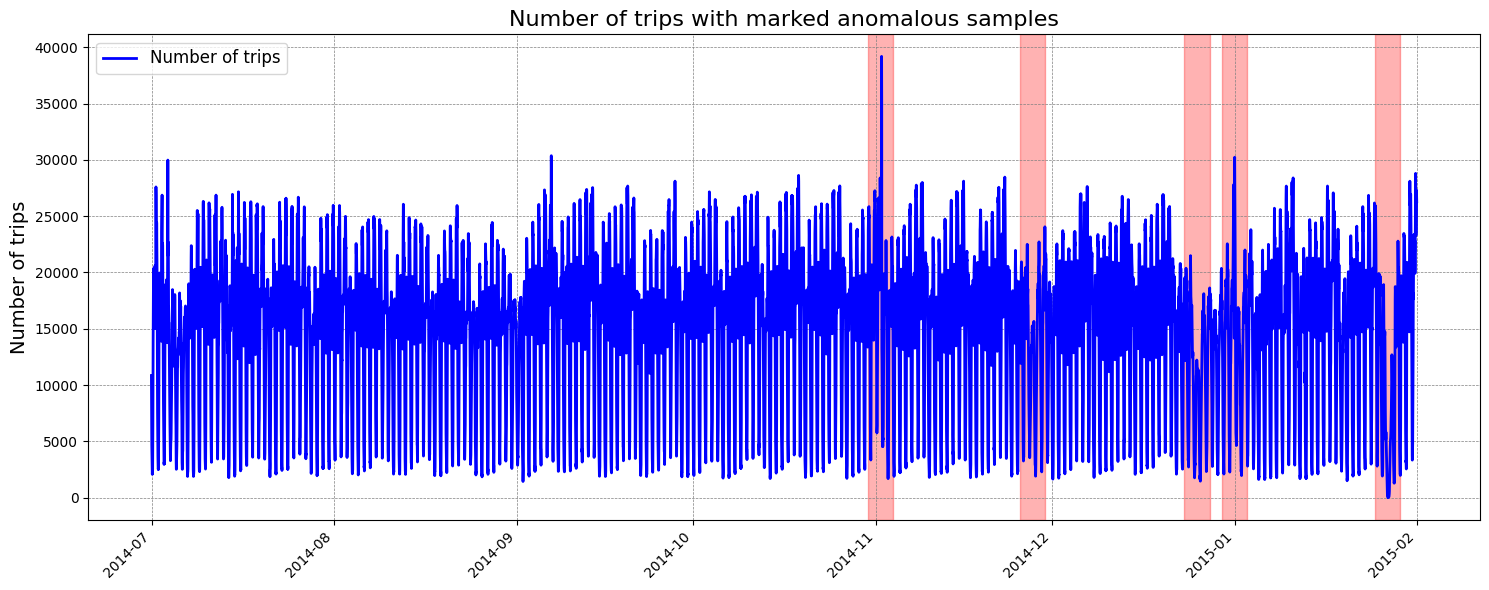

INFO:lightning_fabric.utilities.seed:Seed set to 1
/usr/local/lib/python3.13/dist-packages/neuralforecast/common/_base_model.py:772: UserWarning: val_check_steps is greater than max_steps, setting val_check_steps to max_steps.
  warnings.warn(
INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.callbacks.model_summary:
  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | trai

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_steps=30` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=30` reached.
INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
/usr/local/lib/python3.13/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

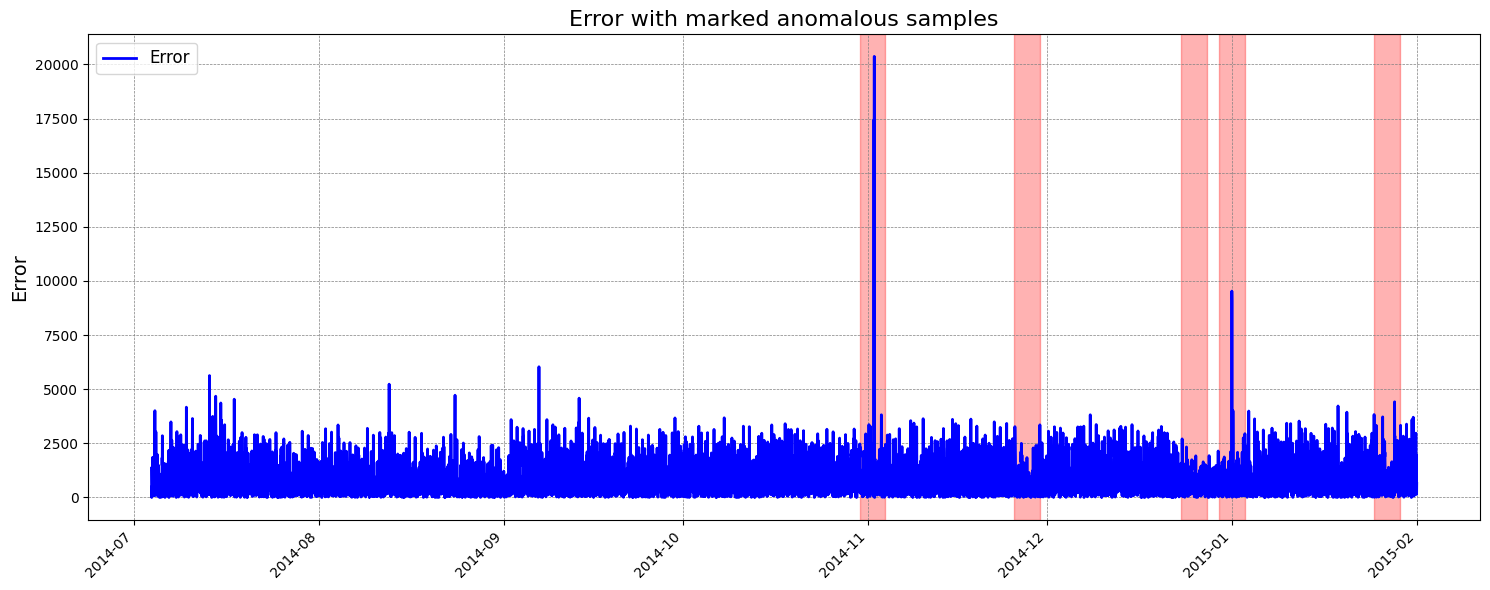

In [17]:
from neuralforecast import NeuralForecast
from neuralforecast.models import NHITS

# Show the raw series with the labeled anomalies
series = dataset.set_index("ds")
setup_plot(series, find_anomaly_periods(series["is_anomaly"]), "Number of trips")

horizon = 1
n_lags = 144   # 144 x 30 min = 3 days

models = [
    NHITS(
        h=horizon,
        input_size=n_lags,
        max_steps=30,
        n_freq_downsample=[2, 1, 1],
        mlp_units=3 * [[128, 128]],
        accelerator="cpu",
    )
]

nf = NeuralForecast(models=models, freq="30min")   # the book writes "30T", same thing
nf.fit(df=dataset.drop("is_anomaly", axis=1), val_size=n_lags)

insample = nf.predict_insample()
insample = insample.tail(-n_lags)
error = (insample["NHITS"] - insample["y"]).abs()

preds = pd.DataFrame({
    "Error": error.values,
    "ds": dataset["ds"].tail(-n_lags).values,
    "is_anomaly": dataset["is_anomaly"].tail(-n_lags).values,
}).set_index("ds")

setup_plot(preds.rename(columns={"Error": "y"}),
           find_anomaly_periods(preds["is_anomaly"]), "Error")

##type 3 : LSTM autoencoder (PyTorch Lightning)

INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities

┏━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type    ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder │ Encoder │    176 │ train │     0 │
│ 1 │ decoder │ Decoder │    181 │ train │     0 │
└───┴─────────┴─────────┴────────┴───────┴───────┘

Trainable params: 357                                                                                              
Non-trainable params: 0                                                                                            
Total params: 357                                                                                                  
Total estimated model params size (MB): 0.001                                                                      
Modules in train mode: 7                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.13/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO: `Trainer.fit` stopped: `max_epochs=3` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=3` reached.


Output()

/usr/local/lib/python3.13/dist-packages/pytorch_forecasting/data/timeseries/_timeseries.py:1723: UserWarning: If predicting, no randomization should be possible - setting stop_randomization=True
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


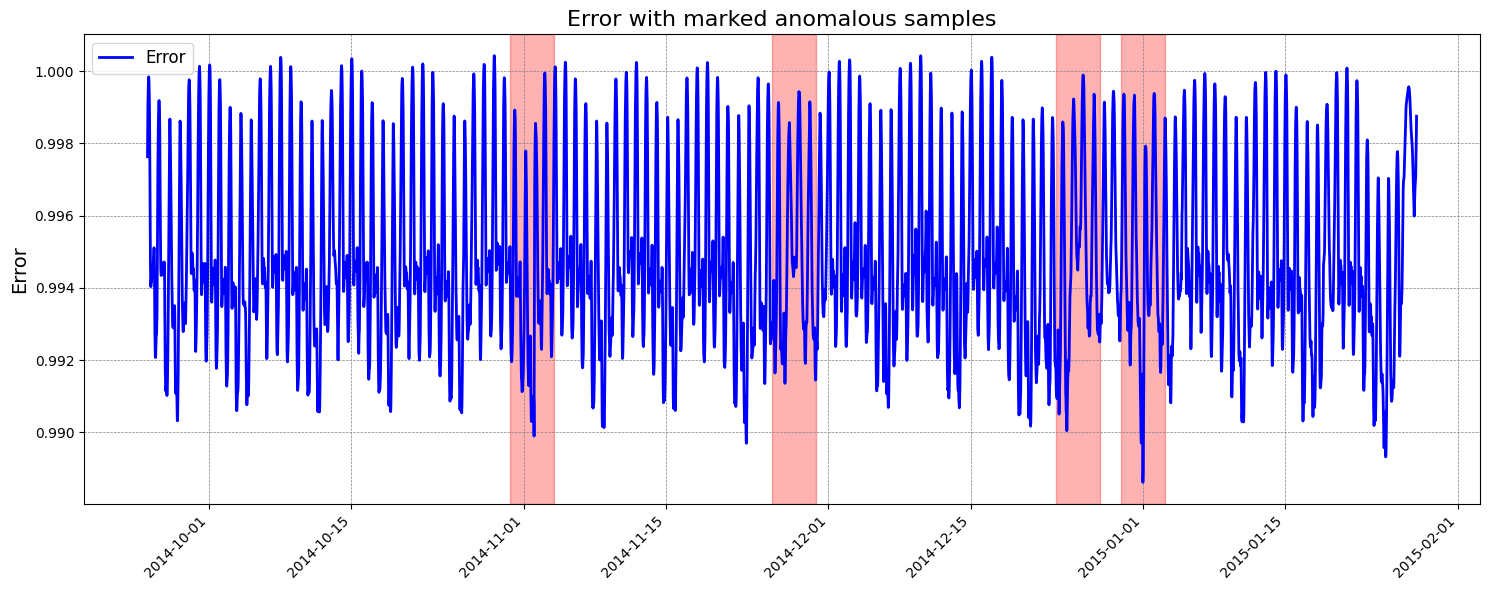

In [18]:
import torch
import torch.nn.functional as F
from torch import nn
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping
from pytorch_forecasting import TimeSeriesDataSet
from sklearn.model_selection import train_test_split

N_LAGS = 192
N_VARIABLES = 1


class TaxiDataModule(pl.LightningDataModule):
    def __init__(self, data: pd.DataFrame, n_lags: int, batch_size: int):
        super().__init__()
        self.data = data
        self.batch_size = batch_size
        self.n_lags = n_lags
        self.train_df = None
        self.test_df = None
        self.training = None
        self.validation = None
        self.predict_set = None

    def setup(self, stage=None):
        self.data["timestep"] = np.arange(self.data.shape[0])
        unique_times = self.data["timestep"].sort_values().unique()

        tr_ind, ts_ind = train_test_split(unique_times, test_size=0.6, shuffle=False)
        tr_ind, vl_ind = train_test_split(tr_ind, test_size=0.1, shuffle=False)

        self.train_df = self.data.loc[self.data["timestep"].isin(tr_ind), :]
        self.test_df = self.data.loc[self.data["timestep"].isin(ts_ind), :]
        validation_df = self.data.loc[self.data["timestep"].isin(vl_ind), :]

        self.training = TimeSeriesDataSet(
            data=self.train_df,
            time_idx="timestep",
            target="y",
            group_ids=["unique_id"],
            max_encoder_length=self.n_lags,
            max_prediction_length=1,
            time_varying_unknown_reals=["y"],
        )
        self.validation = TimeSeriesDataSet.from_dataset(self.training, validation_df)
        self.test = TimeSeriesDataSet.from_dataset(self.training, self.test_df)
        self.predict_set = TimeSeriesDataSet.from_dataset(
            self.training, self.data, predict=True
        )

    def train_dataloader(self):
        return self.training.to_dataloader(batch_size=self.batch_size, shuffle=False)

    def val_dataloader(self):
        return self.validation.to_dataloader(batch_size=self.batch_size, shuffle=False)

    def predict_dataloader(self):
        return self.predict_set.to_dataloader(batch_size=1, shuffle=False)


class Encoder(nn.Module):
    def __init__(self, context_len, n_variables, embedding_dim=64):
        super().__init__()
        self.context_len, self.n_variables = context_len, n_variables
        self.embedding_dim, self.hidden_dim = embedding_dim, 2 * embedding_dim
        self.lstm1 = nn.LSTM(input_size=self.n_variables, hidden_size=self.hidden_dim,
                             num_layers=1, batch_first=True)
        self.lstm2 = nn.LSTM(input_size=self.hidden_dim, hidden_size=embedding_dim,
                             num_layers=1, batch_first=True)

    def forward(self, x):
        batch_size = x.shape[0]
        x, (_, _) = self.lstm1(x)
        x, (hidden_n, _) = self.lstm2(x)
        return hidden_n.reshape((batch_size, self.embedding_dim))


class Decoder(nn.Module):
    def __init__(self, context_len, n_variables=1, input_dim=64):
        super().__init__()
        self.context_len, self.input_dim = context_len, input_dim
        self.hidden_dim, self.n_variables = 2 * input_dim, n_variables
        self.lstm1 = nn.LSTM(input_size=input_dim, hidden_size=input_dim,
                             num_layers=1, batch_first=True)
        self.lstm2 = nn.LSTM(input_size=input_dim, hidden_size=self.hidden_dim,
                             num_layers=1, batch_first=True)
        self.output_layer = nn.Linear(self.hidden_dim, self.n_variables)

    def forward(self, x):
        batch_size = x.shape[0]
        x = x.repeat(self.context_len, self.n_variables)
        x = x.reshape((batch_size, self.context_len, self.input_dim))
        x, (hidden_n, cell_n) = self.lstm1(x)
        x, (hidden_n, cell_n) = self.lstm2(x)
        x = x.reshape((batch_size, self.context_len, self.hidden_dim))
        return self.output_layer(x)


class AutoencoderLSTM(pl.LightningModule):
    def __init__(self, context_len, n_variables, embedding_dim):
        super().__init__()
        self.encoder = Encoder(context_len, n_variables, embedding_dim)
        self.decoder = Decoder(context_len, n_variables, embedding_dim)

    def forward(self, x):
        xh = self.encoder(x)
        return self.decoder(xh)

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x["encoder_cont"])
        loss = F.mse_loss(y_pred, x["encoder_cont"])
        self.log("train_loss", loss)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x["encoder_cont"])
        loss = F.mse_loss(y_pred, x["encoder_cont"])
        self.log("val_loss", loss)
        return loss

    def predict_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x["encoder_cont"])
        return F.mse_loss(y_pred, x["encoder_cont"])   # reconstruction error

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.001)


# ---------- Train ----------
datamodule = TaxiDataModule(
    data=dataset.drop("is_anomaly", axis=1).copy(), n_lags=N_LAGS, batch_size=64
)
model = AutoencoderLSTM(n_variables=1, context_len=N_LAGS, embedding_dim=2)

early_stop_callback = EarlyStopping(
    monitor="val_loss", min_delta=1e-4, patience=5, verbose=False, mode="min"
)
trainer = pl.Trainer(max_epochs=3, accelerator="cpu", callbacks=[early_stop_callback])
trainer.fit(model, datamodule)

# ---------- Reconstruction error on the test set ----------
dl = datamodule.test.to_dataloader(batch_size=1, shuffle=False)
preds = trainer.predict(model, dataloaders=dl)
preds = pd.Series(np.array([x.numpy() for x in preds]))

test = datamodule.test_df.head(len(preds))
is_anom = dataset.loc[test.index, :]["is_anomaly"].values

preds.index = test["ds"].values
preds_df = preds.reset_index()
preds_df.columns = ["ds", "Error"]
preds_df["is_anomaly"] = is_anom
preds_df = preds_df.set_index("ds")

setup_plot(preds_df.rename(columns={"Error": "y"}),
           find_anomaly_periods(preds_df["is_anomaly"]), "Error")

##type 4 : Autoencoder with PyOD

InnerAutoencoder(
  (activation): ReLU()
  (encoder): Sequential(
    (linear0): Linear(in_features=144, out_features=144, bias=True)
    (batch_norm0): BatchNorm1d(144, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU()
    (dropout0): Dropout(p=0.2, inplace=False)
    (linear1): Linear(in_features=144, out_features=4, bias=True)
    (batch_norm1): BatchNorm1d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu1): ReLU()
    (dropout1): Dropout(p=0.2, inplace=False)
    (linear2): Linear(in_features=4, out_features=4, bias=True)
    (batch_norm2): BatchNorm1d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu2): ReLU()
    (dropout2): Dropout(p=0.2, inplace=False)
    (linear3): Linear(in_features=4, out_features=144, bias=True)
    (batch_norm3): BatchNorm1d(144, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu3): ReLU()
    (dropout3): Dropout(p=0.2, inplace=False)
  )
  (dec

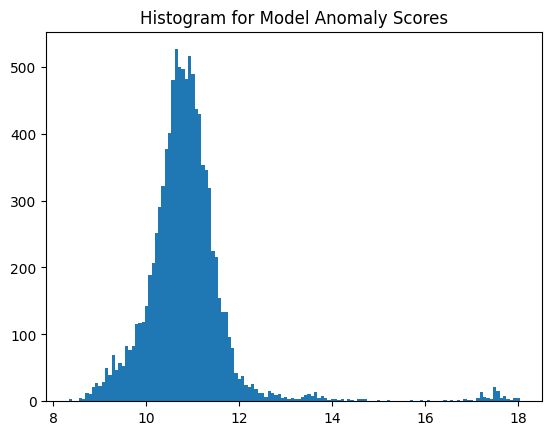

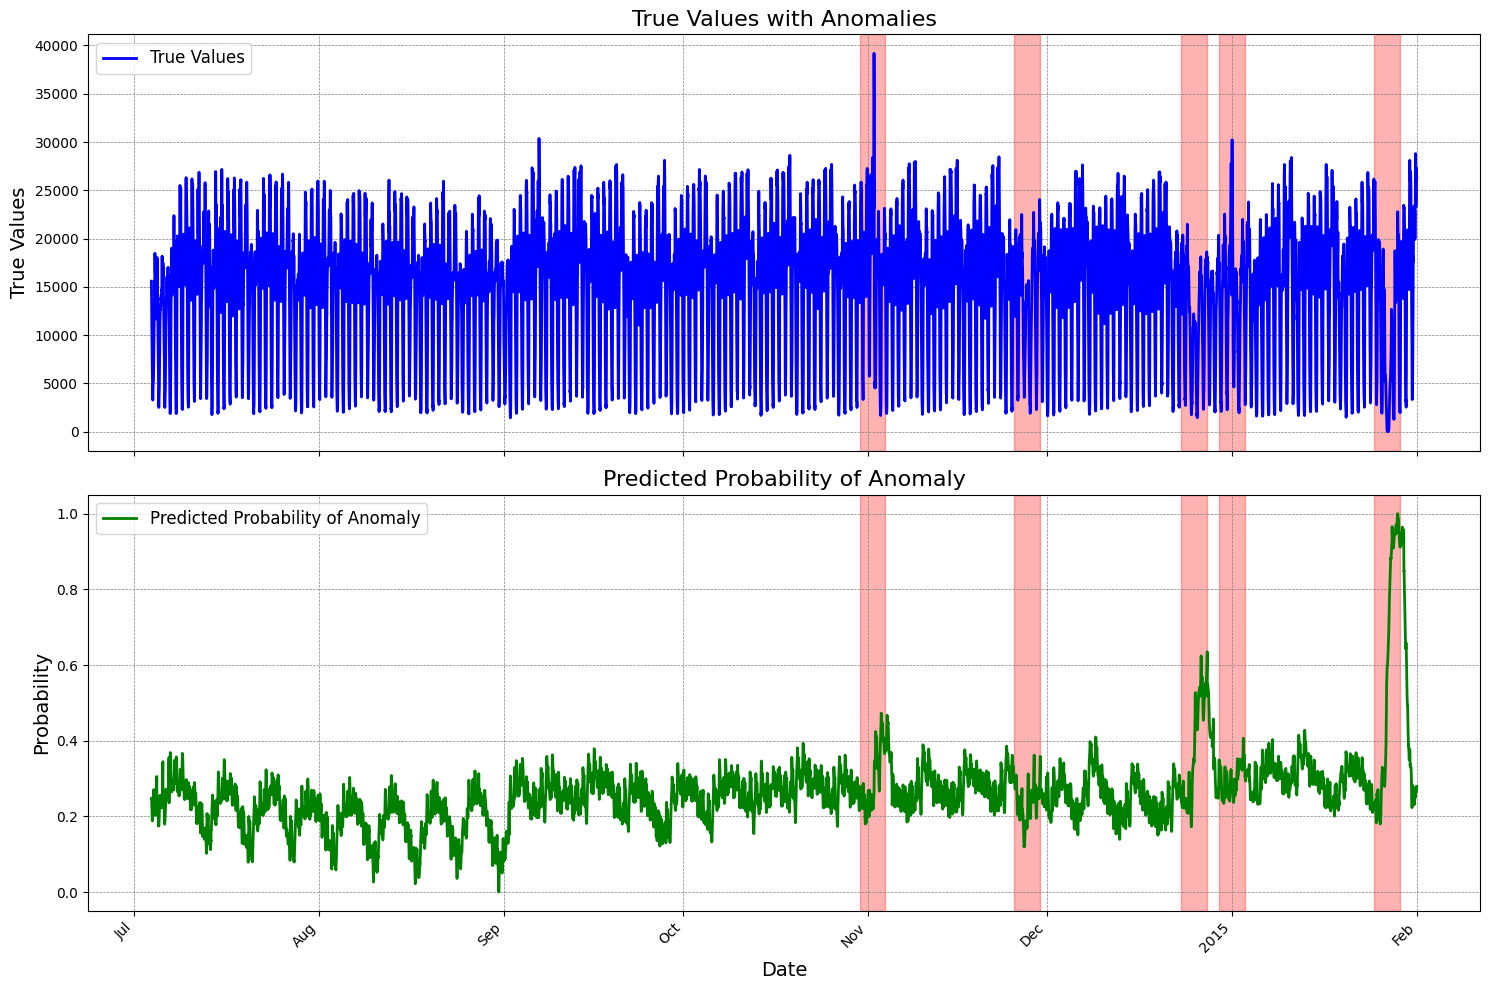

In [19]:
from sklearn.preprocessing import StandardScaler
from pyod.models.auto_encoder_torch import AutoEncoder

N_LAGS = 144

# Sliding window: each row = previous 144 values
series_y = dataset["y"]
input_data = []
for i in range(N_LAGS, series_y.shape[0]):
    input_data.append(series_y.iloc[i - N_LAGS : i].values)

input_data = np.array(input_data)
input_data_n = pd.DataFrame(StandardScaler().fit_transform(input_data))

# Model
model = AutoEncoder(
    hidden_neurons=[144, 4, 4, 144],
    hidden_activation="relu",
    epochs=20,
    batch_norm=True,
    learning_rate=0.001,
    batch_size=32,
    dropout_rate=0.2,
)
model.fit(input_data_n)

# Scores
anomaly_scores = model.decision_scores_
plt.hist(anomaly_scores, bins="auto")
plt.title("Histogram for Model Anomaly Scores")
plt.show()

probs = model.predict_proba(input_data_n)[:, 1]
probabilities = pd.Series(probs, index=series_y.tail(len(probs)).index)

ds = dataset.tail(-N_LAGS).copy()
ds["Predicted Probability"] = probabilities
ds = ds.set_index("ds")

setup_plot_prob(ds, find_anomaly_periods(ds["is_anomaly"]))

## type 5 : Variational autoencoder (PyOD, TensorFlow/Keras)

Epoch  1/20  loss = 153.6342
Epoch  2/20  loss = 131.4192
Epoch  3/20  loss = 121.2468
Epoch  4/20  loss = 116.7621
Epoch  5/20  loss = 115.4901
Epoch  6/20  loss = 115.1256
Epoch  7/20  loss = 114.1138
Epoch  8/20  loss = 113.8336
Epoch  9/20  loss = 112.2183
Epoch 10/20  loss = 108.1416
Epoch 11/20  loss = 103.5921
Epoch 12/20  loss = 102.8662
Epoch 13/20  loss = 100.9935
Epoch 14/20  loss = 101.3110
Epoch 15/20  loss = 100.7188
Epoch 16/20  loss = 99.9606
Epoch 17/20  loss = 98.6582
Epoch 18/20  loss = 98.9154
Epoch 19/20  loss = 97.2594
Epoch 20/20  loss = 97.3532


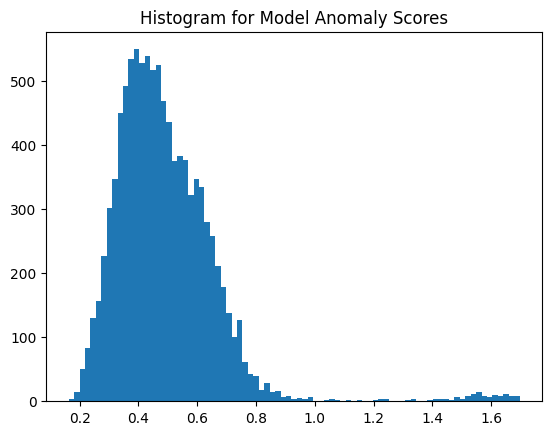

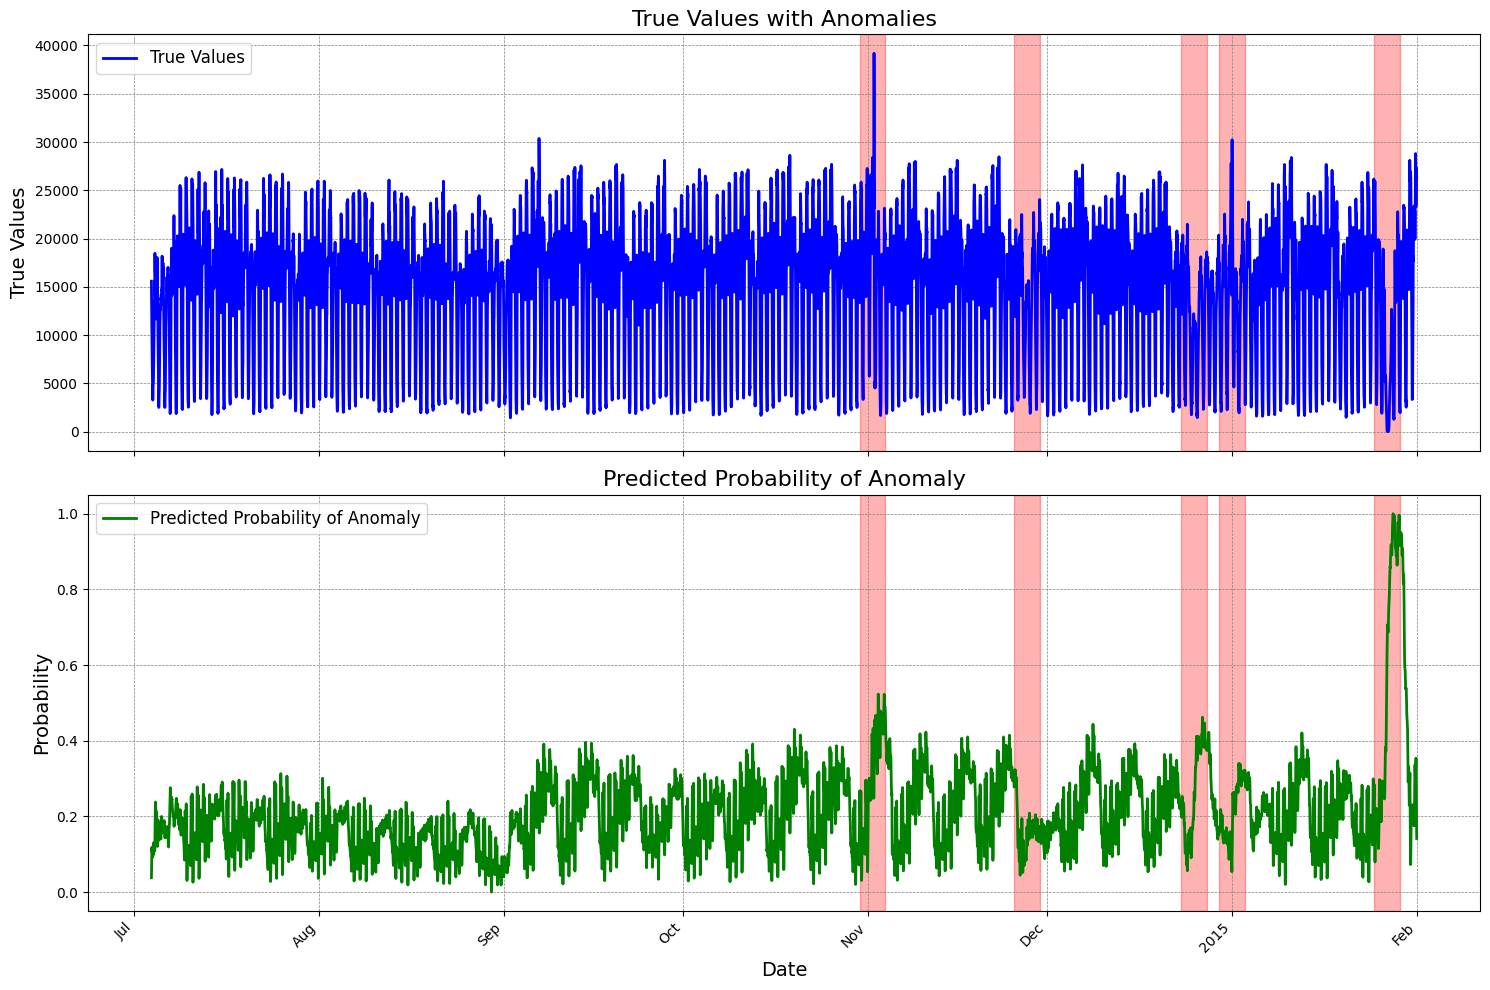

In [20]:
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

torch.manual_seed(42)
np.random.seed(42)

N_LAGS = 144

# ---------- 1. Sliding windows + scaling (same as the book) ----------
series_y = dataset["y"]
input_data = []
for i in range(N_LAGS, series_y.shape[0]):
    input_data.append(series_y.iloc[i - N_LAGS : i].values)

input_data = np.array(input_data)
X = StandardScaler().fit_transform(input_data).astype(np.float32)
X_t = torch.tensor(X)

# ---------- 2. The VAE: 144 -> 4 -> (latent 2) -> 4 -> 144 ----------
class VAE(nn.Module):
    def __init__(self, n_in=144, hidden=4, latent=2, dropout=0.2):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(n_in, hidden), nn.ReLU(), nn.Dropout(dropout)
        )
        self.fc_mu = nn.Linear(hidden, latent)       # mean of the latent distribution
        self.fc_logvar = nn.Linear(hidden, latent)   # log-variance of the latent distribution
        self.decoder = nn.Sequential(
            nn.Linear(latent, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, n_in),
        )

    def forward(self, x):
        h = self.encoder(x)
        mu, logvar = self.fc_mu(h), self.fc_logvar(h)
        if self.training:                      # sample while training
            std = torch.exp(0.5 * logvar)
            z = mu + std * torch.randn_like(std)
        else:                                  # use the mean when scoring
            z = mu
        return self.decoder(z), mu, logvar


def vae_loss(recon, x, mu, logvar):
    recon_loss = F.mse_loss(recon, x, reduction="sum") / x.shape[0]
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.shape[0]
    return recon_loss + kl, recon_loss, kl

# ---------- 3. Train ----------
model = VAE(n_in=N_LAGS, hidden=4, latent=2, dropout=0.2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loader = DataLoader(TensorDataset(X_t), batch_size=32, shuffle=True)

EPOCHS = 20
for epoch in range(EPOCHS):
    model.train()
    total = 0.0
    for (xb,) in loader:
        optimizer.zero_grad()
        recon, mu, logvar = model(xb)
        loss, rec, kl = vae_loss(recon, xb, mu, logvar)
        loss.backward()
        optimizer.step()
        total += loss.item() * xb.shape[0]
    print(f"Epoch {epoch + 1:2d}/{EPOCHS}  loss = {total / len(X_t):.4f}")

# ---------- 4. Anomaly score = reconstruction error of each window ----------
model.eval()
with torch.no_grad():
    recon, mu, logvar = model(X_t)
    anomaly_scores = ((recon - X_t) ** 2).mean(dim=1).numpy()

plt.hist(anomaly_scores, bins="auto")
plt.title("Histogram for Model Anomaly Scores")
plt.show()

# Rescale scores to 0-1 (same idea as PyOD's predict_proba)
probs = (anomaly_scores - anomaly_scores.min()) / (anomaly_scores.max() - anomaly_scores.min())
probabilities = pd.Series(probs, index=series_y.tail(len(probs)).index)

ds = dataset.tail(-N_LAGS).copy()
ds["Predicted Probability"] = probabilities
ds = ds.set_index("ds")

setup_plot_prob(ds, find_anomaly_periods(ds["is_anomaly"]))

##type 6 : GAN (PyOD AnoGAN)

Epoch  1/20  D loss = 1.340   G loss = 0.813
Epoch  2/20  D loss = 1.065   G loss = 1.143
Epoch  3/20  D loss = 0.724   G loss = 1.817
Epoch  4/20  D loss = 0.565   G loss = 2.364
Epoch  5/20  D loss = 0.325   G loss = 2.953
Epoch  6/20  D loss = 0.275   G loss = 3.448
Epoch  7/20  D loss = 0.239   G loss = 3.978
Epoch  8/20  D loss = 0.216   G loss = 4.294
Epoch  9/20  D loss = 0.172   G loss = 4.583
Epoch 10/20  D loss = 0.298   G loss = 4.501
Epoch 11/20  D loss = 0.234   G loss = 4.459
Epoch 12/20  D loss = 0.346   G loss = 4.270
Epoch 13/20  D loss = 0.396   G loss = 3.812
Epoch 14/20  D loss = 0.581   G loss = 3.204
Epoch 15/20  D loss = 0.486   G loss = 3.275
Epoch 16/20  D loss = 0.531   G loss = 3.174
Epoch 17/20  D loss = 0.561   G loss = 2.936
Epoch 18/20  D loss = 0.692   G loss = 2.618
Epoch 19/20  D loss = 0.654   G loss = 2.423
Epoch 20/20  D loss = 0.721   G loss = 2.210


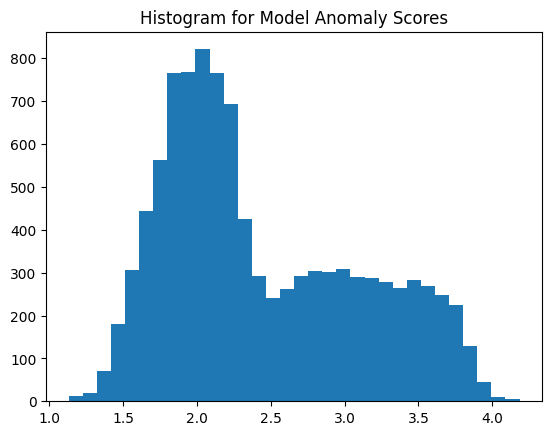

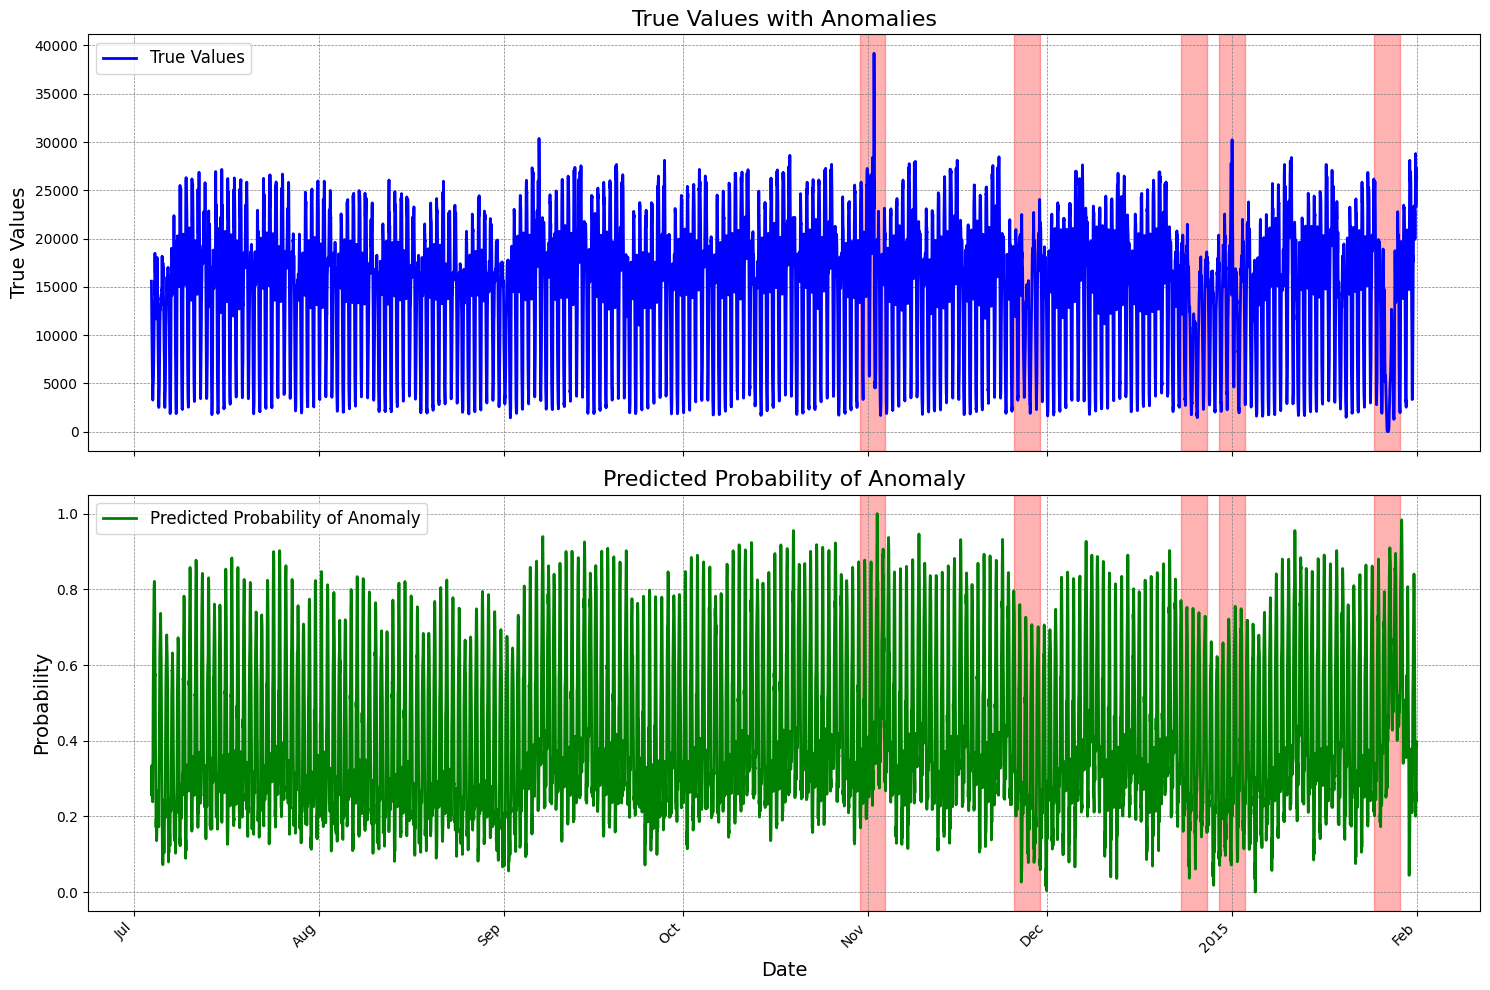

In [22]:
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)
np.random.seed(42)

N_LAGS = 144
LATENT_DIM = 2

# ---------- 1. Sliding windows + scaling (same as the book) ----------
series_y = dataset["y"]
input_data = []
for i in range(N_LAGS, series_y.shape[0]):
    input_data.append(series_y.iloc[i - N_LAGS : i].values)

input_data = np.array(input_data)
X = StandardScaler().fit_transform(input_data).astype(np.float32)
X_t = torch.tensor(X)

# ---------- 2. Generator: noise (2 numbers) -> fake window (144 values) ----------
class Generator(nn.Module):
    def __init__(self, latent_dim=2, n_out=144, layers=(20, 10, 3, 10, 20), dropout=0.2):
        super().__init__()
        blocks, prev = [], latent_dim
        for units in layers:
            blocks += [nn.Linear(prev, units), nn.Tanh(), nn.Dropout(dropout)]
            prev = units
        blocks.append(nn.Linear(prev, n_out))      # linear output
        self.net = nn.Sequential(*blocks)

    def forward(self, z):
        return self.net(z)

# ---------- 3. Discriminator: window -> real/fake score (+ inner features) ----------
class Discriminator(nn.Module):
    def __init__(self, n_in=144, dropout=0.2):
        super().__init__()
        self.l1 = nn.Sequential(nn.Linear(n_in, 20), nn.Tanh(), nn.Dropout(dropout))
        self.l2 = nn.Sequential(nn.Linear(20, 10), nn.Tanh(), nn.Dropout(dropout))  # feature layer
        self.l3 = nn.Sequential(nn.Linear(10, 5), nn.Tanh(), nn.Dropout(dropout))
        self.out = nn.Linear(5, 1)

    def forward(self, x):
        f1 = self.l1(x)
        f2 = self.l2(f1)             # inner features used later for scoring
        logit = self.out(self.l3(f2))
        return logit, f2

G = Generator(LATENT_DIM, N_LAGS)
D = Discriminator(N_LAGS)
bce = nn.BCEWithLogitsLoss()
opt_g = torch.optim.Adam(G.parameters(), lr=0.001)
opt_d = torch.optim.Adam(D.parameters(), lr=0.001)
loader = DataLoader(TensorDataset(X_t), batch_size=32, shuffle=True)

# ---------- 4. Train the GAN (the two networks compete) ----------
EPOCHS = 20
for epoch in range(EPOCHS):
    G.train(); D.train()
    d_tot, g_tot = 0.0, 0.0
    for (real,) in loader:
        b = real.shape[0]
        ones, zeros = torch.ones(b, 1), torch.zeros(b, 1)

        # (a) Train the discriminator: real -> 1, fake -> 0
        fake = G(torch.randn(b, LATENT_DIM))
        loss_d = bce(D(real)[0], ones) + bce(D(fake.detach())[0], zeros)
        opt_d.zero_grad(); loss_d.backward(); opt_d.step()

        # (b) Train the generator: try to make the discriminator say "real"
        loss_g = bce(D(fake)[0], ones)
        opt_g.zero_grad(); loss_g.backward(); opt_g.step()

        d_tot += loss_d.item() * b
        g_tot += loss_g.item() * b
    print(f"Epoch {epoch + 1:2d}/{EPOCHS}  D loss = {d_tot / len(X_t):.3f}   G loss = {g_tot / len(X_t):.3f}")

# ---------- 5. Anomaly score (the AnoGAN step) ----------
# For each window, search for the noise z whose generated window looks most like it.
# Score = how badly the best generated window still matches the real one
#         (pixel-wise error + difference in the discriminator's inner features).
G.eval(); D.eval()
for p in list(G.parameters()) + list(D.parameters()):
    p.requires_grad_(False)

z = torch.randn(len(X_t), LATENT_DIM, requires_grad=True)
opt_z = torch.optim.Adam([z], lr=0.01)          # learning_rate_query
N_QUERY_STEPS = 50

with torch.no_grad():
    _, real_feat = D(X_t)

for step in range(N_QUERY_STEPS):
    gen = G(z)
    _, gen_feat = D(gen)
    per_sample = ((gen - X_t) ** 2).mean(dim=1) + ((gen_feat - real_feat) ** 2).mean(dim=1)
    opt_z.zero_grad()
    per_sample.sum().backward()
    opt_z.step()

with torch.no_grad():
    gen = G(z)
    _, gen_feat = D(gen)
    anomaly_scores = (((gen - X_t) ** 2).mean(dim=1)
                      + ((gen_feat - real_feat) ** 2).mean(dim=1)).numpy()

plt.hist(anomaly_scores, bins="auto")
plt.title("Histogram for Model Anomaly Scores")
plt.show()

# Rescale scores to 0-1
probs = (anomaly_scores - anomaly_scores.min()) / (anomaly_scores.max() - anomaly_scores.min())
probabilities = pd.Series(probs, index=series_y.tail(len(probs)).index)

ds = dataset.tail(-N_LAGS).copy()
ds["Predicted Probability"] = probabilities
ds = ds.set_index("ds")

setup_plot_prob(ds, find_anomaly_periods(ds["is_anomaly"]))